Install libraries

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

Set paths

In [4]:
TRAIN_DIR = '/content/chest_xray/train'
VAL_DIR   = '/content/chest_xray/val'
TEST_DIR  = '/content/chest_xray/test'

check class count

In [38]:
for split in [TRAIN_DIR, TEST_DIR]:
    for cls in os.listdir(split):
        count = len(os.listdir(os.path.join(split, cls)))
        print(f"{split.split('/')[-1]} | {cls}: {count} images")

train | NORMAL: 1341 images
train | PNEUMONIA: 3875 images
test | NORMAL: 234 images
test | PNEUMONIA: 390 images


EDA

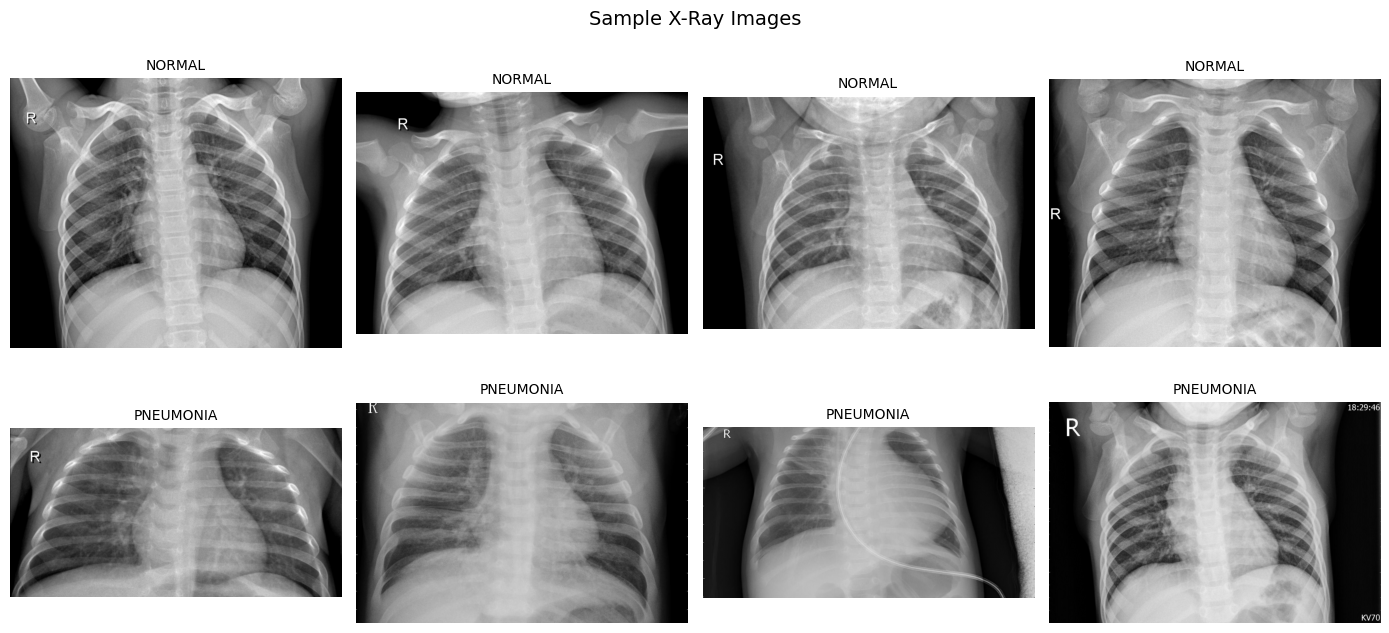

In [39]:
import cv2
from PIL import Image
import random

# sample images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(TRAIN_DIR, cls)
    files  = random.sample(os.listdir(folder), 4)
    for j, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(cls, fontsize=10)
        axes[i][j].axis('off')
plt.suptitle('Sample X-Ray Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png')

Image size

In [40]:
widths, heights = [], []
for cls in ['NORMAL', 'PNEUMONIA']:
    folder = os.path.join(TRAIN_DIR, cls)
    for f in os.listdir(folder)[:100]:
        img = Image.open(os.path.join(folder, f))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Avg width:  {np.mean(widths):.0f}px")
print(f"Avg height: {np.mean(heights):.0f}px")
print(f"We resize all to: 224x224")

Avg width:  1441px
Avg height: 1101px
We resize all to: 224x224


Class distribution bar chart

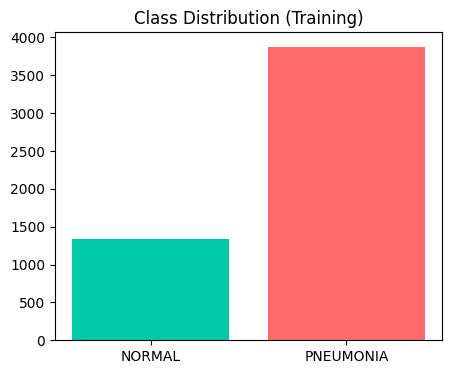

In [41]:
classes = ['NORMAL', 'PNEUMONIA']
counts  = [1341, 3875]
plt.figure(figsize=(5, 4))
plt.bar(classes, counts, color=['#00c9a7', '#ff6b6b'])
plt.title('Class Distribution (Training)')
plt.savefig('class_dist.png')

Data Preprocessing & Augmentation

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

Test/Val: ONLY rescale, no augmentation

In [42]:
test_gen = ImageDataGenerator(rescale=1./255)

 Load images from folders

In [43]:
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
val_data = test_gen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


 Handle class imbalance with class weights

In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_data.classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


Build CNN

In [45]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,729 (73.49 MB)

 Trainable params: 19,264,769 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

Transfer Learning with VGG16

In [46]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model weights
base_model.trainable = False

# Add our own classification head on top
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

#  Fine-tuning
def fine_tune(model, base, layers_to_unfreeze=4):
    base.trainable = True
    # Freeze all except last N layers
    for layer in base.layers[:-layers_to_unfreeze]:
        layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    return model

Training with Callbacks

In [47]:
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    # Save best model automatically
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),
]

 Train model

In [18]:
history = tl_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 722ms/step - accuracy: 0.6409 - auc: 0.7113 - loss: 0.6327 - val_accuracy: 0.7500 - val_auc: 0.9375 - val_loss: 0.5387 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 665ms/step - accuracy: 0.8169 - auc: 0.8973 - loss: 0.4663 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.4321 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.8560 - auc: 0.9337 - loss: 0.3485 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.4250 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 669ms/step - accuracy: 0.8754 - auc: 0.9468 - loss: 0.2966 - val_accuracy: 0.8125 - val_auc: 0.9453 - val_loss: 0.4242 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 664ms/step - accuracy: 0.8877 - auc: 0.9544 - loss: 0.2703 - val_accuracy: 0.8125 - val_auc: 0.9531 - val_loss: 0.4683 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 

 Plot training curves

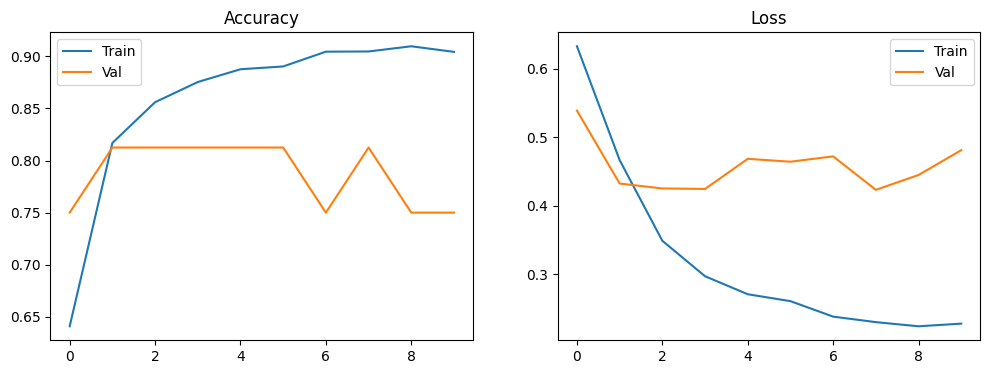

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'],    label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],    label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.savefig('training_curves.png')

Evaluation & Metrics

In [20]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import seaborn as sns

y_pred_proba = tl_model.predict(test_data)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step


Classification Report

In [50]:
print(classification_report(
    y_true, y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.78      0.86      0.82       234
   PNEUMONIA       0.91      0.85      0.88       390

    accuracy                           0.86       624
   macro avg       0.85      0.86      0.85       624
weighted avg       0.86      0.86      0.86       624



Confusion Matrix

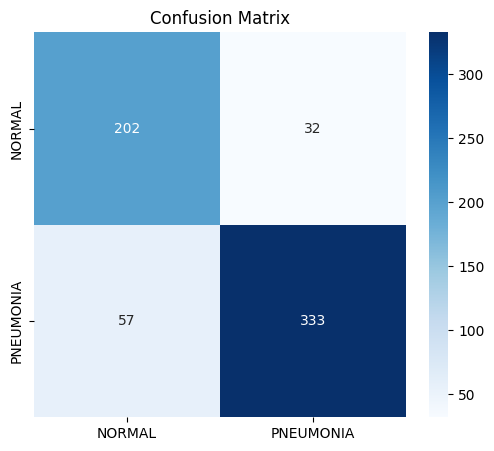

In [51]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

ROC-AUC

Final AUC: 0.9354


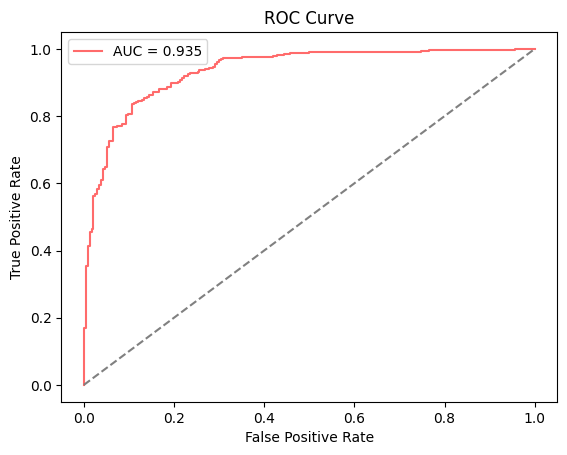

In [52]:
auc = roc_auc_score(y_true, y_pred_proba)
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#ff6b6b')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png')
print(f"Final AUC: {auc:.4f}")

Grad-CAM Visualization

In [26]:
import cv2
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [30]:
TEST_DIR = '/content/chest_xray/test'

def make_gradcam_heatmap(img_array, model, last_conv_layer):
    grad_model = Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]


    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

Load and preprocess image

In [35]:
def show_gradcam(img_path, model, last_conv='block5_conv3'):

    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array / 255., axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv)

    # Overlay heatmap on original image
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color   = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    img_orig = np.array(img)
    overlay  = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title('Original X-Ray')
    axes[1].imshow(overlay)
    axes[1].set_title('Grad-CAM: Where model looks')
    plt.savefig('gradcam.png', bbox_inches='tight')


Run on a pneumonia test image

Using image: /content/chest_xray/test/PNEUMONIA/person64_virus_122.jpeg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_17']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


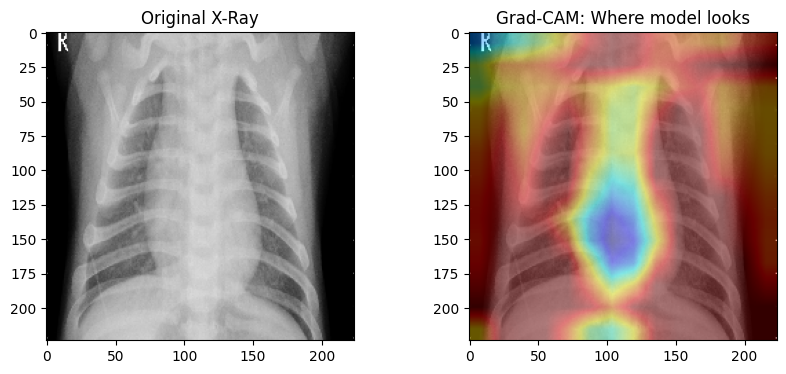

In [33]:
import os
test_img = os.path.join(TEST_DIR, 'PNEUMONIA', os.listdir(TEST_DIR + '/PNEUMONIA')[0])
print("Using image:", test_img)
show_gradcam(test_img, tl_model)